In [1]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\Steve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
study = optuna.load_study(
    storage=r"sqlite:///pre_infer.sqlite3",
    study_name="resnet_50_64img_1pls_2sample_pre_infer_fullZ_all",
)

SCALE = 8

In [9]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
df.to_csv("data.csv",index=False)

df["duration"].sum()

Timedelta('2 days 09:29:51.094762')

In [8]:
df_failed = df[df.value == 0.825]
df_unchanged = df[df.value == 0.6875]
df_one = df[df.value == 0.671875]
df_success = df[df.value < 0.5]

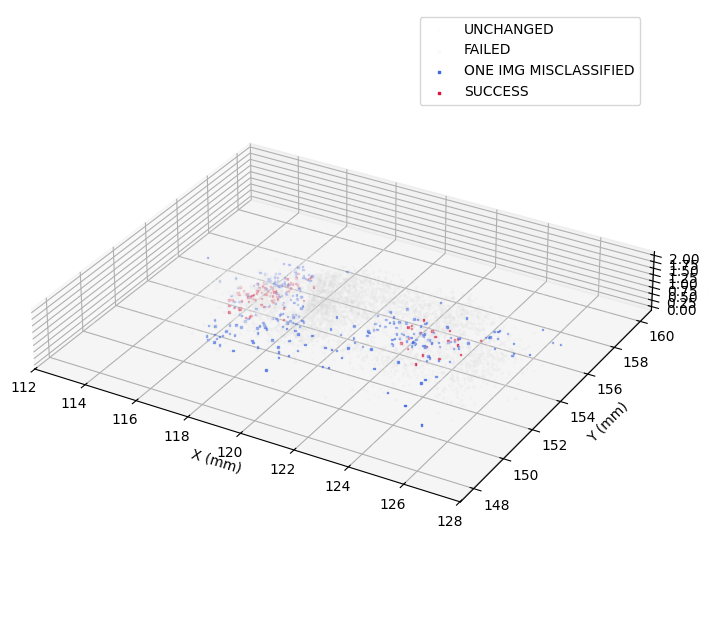

In [9]:
fig = plt.figure(figsize=(SCALE, SCALE))
ax = fig.add_subplot(111, projection="3d")

x_range = df["params_x"].max() - df["params_x"].min()
y_range = df["params_y"].max() - df["params_y"].min()
z_range = df["params_z"].max() - df["params_z"].min()

ax.set_box_aspect((x_range, y_range, z_range))

ax.scatter(
    df_unchanged["params_x"],
    df_unchanged["params_y"],
    df_unchanged["params_z"],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
    alpha=0.1,
)

ax.scatter(
    df_failed["params_x"],
    df_failed["params_y"],
    df_failed["params_z"],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
    alpha=0.1,
)

ax.scatter(
    df_one["params_x"],
    df_one["params_y"],
    df_one["params_z"],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)

ax.scatter(
    df_success["params_x"],
    df_success["params_y"],
    df_success["params_z"],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.legend()

plt.savefig("3d.svg")

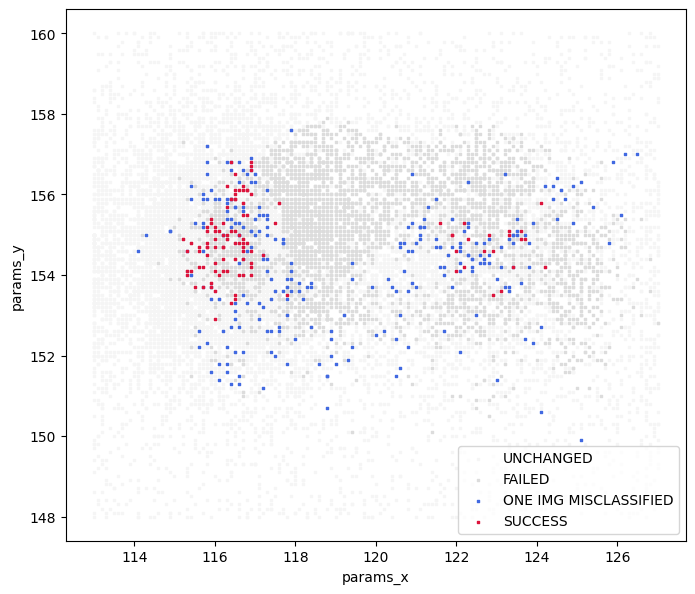

In [10]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
)
plt.savefig("2d_1.svg")
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
)
plt.savefig("2d_2.svg")
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)
plt.savefig("2d_3.svg")
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("2d.svg")

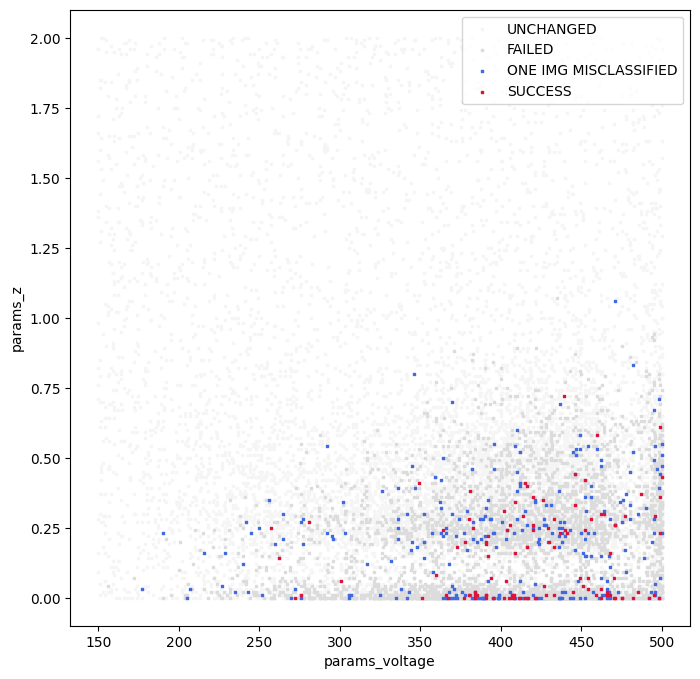

In [11]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

# ax.set_aspect("equal")

param_x = "params_voltage"
param_y = "params_z"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("z_vs_voltage.svg")

In [12]:
df.describe()

,number,value,datetime_start,datetime_complete,duration,params_voltage,params_width,params_x,params_y,params_z
count,16258.000000,16258.000000,16258,16258,16258,16258.000000,16258.000000,16258.000000,16258.000000,16258.000000
mean,8134.066859,0.714367,2026-04-07 12:52:47.719613,2026-04-07 12:53:00.451258,0 days 00:00:12.731645,382.820212,1.507566,118.718785,154.532378,0.399264
min,0.000000,0.000000,2026-04-04 18:42:20.290487,2026-04-04 18:42:28.466015,0 days 00:00:04.843010,150.000000,1.000000,113.000000,148.000000,0.000000
25%,4065.250000,0.687500,2026-04-05 14:44:35.085270,2026-04-05 14:44:42.015000,0 days 00:00:06.818413,339.000000,1.000000,115.900000,153.300000,0.090000
50%,8135.500000,0.687500,2026-04-07 01:01:19.857728,2026-04-07 01:01:40.508450,0 days 00:00:07.169602,399.000000,1.000000,117.800000,154.600000,0.280000
75%,12201.750000,0.687500,2026-04-09 12:45:47.457532,2026-04-09 12:45:55.120947,0 days 00:00:07.851702,444.000000,2.000000,121.600000,155.900000,0.520000
max,16267.000000,0.825000,2026-04-10 03:31:30.543725,2026-04-10 03:32:05.381003,0 days 00:01:43.410444,500.000000,3.000000,127.000000,160.000000,2.000000
std,4697.194574,0.081438,NaN,NaN,0 days 00:00:11.211006,81.284856,0.669072,3.557153,2.159708,0.423986
